#**Load Dataset**

In [92]:
# ============================================================
# IMPORT LIBRARIES & LOAD DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "youtube_trending_videos_global_daily.parquet"

df_raw = pd.read_parquet(DATA_PATH)

df_raw.head()

,video_id,video_published_at,video_trending__date,video_trending_country,channel_id,video_title,video_description,video_default_thumbnail,video_category_id,video_tags,...,channel_description,channel_custom_url,channel_published_at,channel_country,channel_view_count,channel_subscriber_count,channel_have_hidden_subscribers,channel_video_count,channel_localized_title,channel_localized_description
0,b5aMbsJq_EI,2026-08-14T07:00:07Z,2026.08.14,United Arab Emirates,UCLdxVW6ThAB8k5YwiF7MD9w,Tera Mera Rishta 2.0 - Mustafa Zahid,Tera Mera Rishta 2.0 - Mustafa Zahid Almost ...,https://i.ytimg.com/vi/b5aMbsJq_EI/default.jpg,Music,"MustafaZahid,Bollywood,ekvillain,aashiqui2,awa...",...,Official channel of Mustafa Zahid & ROXEN. F...,@mustafazahidofficial,2017-04-10T21:45:25Z,United Arab Emirates,108435399,434000,False,26,Mustafa Zahid,Official channel of Mustafa Zahid & ROXEN. F...
1,fk0JHh1P9H0,2026-08-14T11:30:13Z,2026.08.14,United Arab Emirates,UCPvtzpmgq3fraUXl6lLoK3w,Bethlehem Kudumba Unit Official Trailer | Giri...,Here's the Official Trailer of Bethlehem Kudum...,https://i.ytimg.com/vi/fk0JHh1P9H0/default.jpg,Entertainment,"Bethlehem Kudumba Unit,Bethlehem Kudumba Unit ...",...,Movie production company co-founded by Fahadh ...,@bhavanastudios,2018-12-07T08:05:03Z,India,459886125,592000,False,316,BHAVANA STUDIOS,Movie production company co-founded by Fahadh ...
2,UbP0gW64NYY,2026-08-14T15:48:46Z,2026.08.14,United Arab Emirates,UC27pyUnJTUyxe_z_0WxxNXw,PMWC WATCHPARTY Grand Finals Day 1,Join this channel to get access to perks: http...,https://i.ytimg.com/vi/UbP0gW64NYY/default.jpg,Gaming,,...,"Hey guys! My name is Sanjan Gautam, aka your o...",@cr7horaayt,2019-09-11T09:42:53Z,India,121631908,981000,False,529,Cr7 HORAA,"Hey guys! My name is Sanjan Gautam, aka your o..."
3,6pndxhHFzls,2026-08-10T10:30:51Z,2026.08.14,United Arab Emirates,UCFlwDAcZ1o9AwGbfCoFm57A,Pirisham,Provided to YouTube by Virgin Music Group Pir...,https://i.ytimg.com/vi/6pndxhHFzls/default.jpg,Music,"Najran Kabeer,Pirisham",...,,<NA>,2026-08-10T11:36:49.991131Z,<NA>,0,40,False,0,Najran Kabeer - Topic,
4,DnCRnZhlK04,2026-08-14T13:14:23Z,2026.08.14,United Arab Emirates,UCEBP12AdzxO2_UxFNKCe3ig,Bathlahem Kudumba Unit Official Trailer Reacti...,#entertainmentkizhi #nivinpauly #mamithabaiju ...,https://i.ytimg.com/vi/DnCRnZhlK04/default.jpg,People & Blogs,,...,കിഴി നിറയെ എന്റർടൈൻമെന്റ്,@entertainmentkizhi9444,2013-02-07T05:16:07Z,India,135180436,232000,False,4243,Entertainment Kizhi,കിഴി നിറയെ എന്റർടൈൻമെന്റ്


#**Initial Data Exploration**

In [73]:
# ============================================================
# INITIAL DATA EXPLORATION
# ============================================================

# Dataset dimensions
print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]:,}")

# Dataset structure
df_raw.info()

# Descriptive statistics
df_raw.describe(include="all")

Rows: 18,993
Columns: 28
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18993 entries, 0 to 18992
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   video_id                         18993 non-null  string
 1   video_published_at               18993 non-null  string
 2   video_trending__date             18993 non-null  string
 3   video_trending_country           18993 non-null  string
 4   channel_id                       18993 non-null  string
 5   video_title                      18993 non-null  string
 6   video_description                18993 non-null  string
 7   video_default_thumbnail          18993 non-null  string
 8   video_category_id                18993 non-null  string
 9   video_tags                       18993 non-null  string
 10  video_duration                   18993 non-null  string
 11  video_dimension                  18993 non-null  string
 12  video_d

,video_id,video_published_at,video_trending__date,video_trending_country,channel_id,video_title,video_description,video_default_thumbnail,video_category_id,video_tags,...,channel_description,channel_custom_url,channel_published_at,channel_country,channel_view_count,channel_subscriber_count,channel_have_hidden_subscribers,channel_video_count,channel_localized_title,channel_localized_description
count,18993,18993,18993,18993,18993,18993,18993,18993,18993,18993,...,18991,17730,18991,14877,18991,18991,18991,18991,18991,18991
unique,9061,8039,1,111,7929,9003,8560,9061,14,6582,...,6434,6997,7925,106,7918,3015,1,2658,7863,6434
top,R7ZbszVLFQs,2026-08-14T13:30:06Z,2026.08.14,United Arab Emirates,UCsSsgPaZ2GSmO6il8Cb5iGA,skibidi toilet 80,,https://i.ytimg.com/vi/R7ZbszVLFQs/default.jpg,Gaming,,...,,@skibidi,2016-06-06T15:19:28Z,United States,20879709527,12900000,False,106,skibidi,
freq,102,103,18993,200,102,102,315,102,10170,4337,...,2282,102,102,3577,102,167,18991,141,102,2282


In [74]:
# Check missing values
missing_values = (
    df_raw.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_values[missing_values > 0]

,0
channel_country,4116
channel_custom_url,1263
video_comment_count,141
video_like_count,123
video_view_count,2
channel_published_at,2
channel_description,2
channel_title,2
channel_subscriber_count,2
channel_view_count,2


# **Data Cleaning, Type Conversion & Validation**

In [111]:
# ============================================================
# DATA CLEANING, TYPE CONVERSION & VALIDATION
# ============================================================

# Create a working copy of the raw dataset
df_clean = df_raw.copy()

print("Initial dataset:")
print(f"Rows: {len(df_clean):,}")
print(f"Columns: {df_clean.shape[1]:,}")


# ------------------------------------------------------------
# 1. SAFE DATETIME CONVERSION
# ------------------------------------------------------------

# Video published timestamp
df_clean["video_published_at"] = pd.to_datetime(
    df_clean["video_published_at"],
    errors="coerce",
    utc=True
)

# Trending date
df_clean["video_trending__date"] = pd.to_datetime(
    df_clean["video_trending__date"],
    errors="coerce"
)

# Channel published timestamp
df_clean["channel_published_at"] = pd.to_datetime(
    df_clean["channel_published_at"],
    errors="coerce",
    utc=True
)

# ------------------------------------------------------------
# 2. Convert numerical columns
# ------------------------------------------------------------

numeric_cols = [
    "video_view_count",
    "video_like_count",
    "video_comment_count",
    "channel_view_count",
    "channel_subscriber_count",
    "channel_video_count"
]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors="coerce"
    ).astype("Int64")


# ------------------------------------------------------------
# 3. Clean text columns
# ------------------------------------------------------------

text_cols = [
    "video_id",
    "video_title",
    "video_category_id",
    "video_trending_country",
    "channel_id",
    "channel_title",
    "channel_country",
    "channel_custom_url"
]

for col in text_cols:
    df_clean[col] = (
        df_clean[col]
        .astype("string")
        .str.strip()
    )


# ------------------------------------------------------------
# 4. Validate duplicate observations
# ------------------------------------------------------------

duplicate_keys = [
    "video_id",
    "video_trending__date",
    "video_trending_country"
]

duplicate_count = df_clean.duplicated(
    subset=duplicate_keys,
    keep=False
).sum()

print("\nDuplicate validation:")
print(f"Duplicate observations: {duplicate_count:,}")
print(f"Original rows: {len(df_raw):,}")
print(f"Clean rows: {len(df_clean):,}")

dtype_comparison = pd.DataFrame({
    "before": df_raw.dtypes.astype(str),
    "after": df_clean.dtypes.astype(str)
})

dtype_comparison

Initial dataset:
Rows: 18,993
Columns: 28

Duplicate validation:
Duplicate observations: 0
Original rows: 18,993
Clean rows: 18,993


,before,after
video_id,string,string
video_published_at,string,"datetime64[ns, UTC]"
video_trending__date,string,datetime64[ns]
video_trending_country,string,string
channel_id,string,string
video_title,string,string
video_description,string,string
video_default_thumbnail,string,string
video_category_id,string,string
video_tags,string,string


# **Data Quality Validation**

In [76]:
# ============================================================
# DATA QUALITY VALIDATION
# ============================================================

# Check missing values after cleaning
missing_after_cleaning = (
    df_clean.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_after_cleaning[missing_after_cleaning > 0]

,0
channel_published_at,8828
channel_country,4116
channel_custom_url,1263
video_comment_count,141
video_like_count,123
video_view_count,2
channel_description,2
channel_title,2
channel_subscriber_count,2
channel_view_count,2


Check for impossible negative numerical values

In [102]:
# ============================================================
# NEGATIVE VALUE VALIDATION
# ============================================================

negative_counts = (
    df_clean[numeric_cols]
    .lt(0)
    .sum()
)

negative_counts = negative_counts[
    negative_counts > 0
]

if negative_counts.empty:
    print("No negative values were found in the numerical columns.")
else:
    print("Negative values detected:")
    print(negative_counts)

No negative values were found in the numerical columns.


#**Youtube-Specific Validation**

In [78]:
# ============================================================
# YOUTUBE-SPECIFIC VALIDATION
# ============================================================
invalid_likes = df_clean[
    df_clean["video_like_count"].notna() &
    df_clean["video_view_count"].notna() &
    (df_clean["video_like_count"] > df_clean["video_view_count"])
]

print(
    f"Rows where likes exceed views: "
    f"{len(invalid_likes):,}"
)

invalid_comments = df_clean[
    df_clean["video_comment_count"].notna() &
    df_clean["video_view_count"].notna() &
    (df_clean["video_comment_count"] > df_clean["video_view_count"])
]

print(
    f"Rows where comments exceed views: "
    f"{len(invalid_comments):,}"
)

Rows where likes exceed views: 0
Rows where comments exceed views: 0


#**Date Consistency Validation**

In [79]:
# ============================================================
# DATE CONSISTENCY VALIDATION
# ============================================================

# Videos should not be published after their trending date
invalid_video_dates = df_clean[
    df_clean["video_published_at"].notna() &
    df_clean["video_trending__date"].notna() &
    (
        df_clean["video_published_at"].dt.date
        > df_clean["video_trending__date"].dt.date
    )
]

print(
    f"Videos published after trending date: "
    f"{len(invalid_video_dates):,}"
)


# Channels should not be created after video publication
invalid_channel_dates = df_clean[
    df_clean["channel_published_at"].notna() &
    df_clean["video_published_at"].notna() &
    (
        df_clean["channel_published_at"]
        > df_clean["video_published_at"]
    )
]

print(
    f"Channels published after video publication: "
    f"{len(invalid_channel_dates):,}"
)

Videos published after trending date: 0
Channels published after video publication: 0


Quest 1: Highest-Liked Unique Video

In [94]:
# ============================================================
# QUEST 1: HIGHEST-LIKED UNIQUE VIDEO
# ============================================================

video_level_likes = (
    df_clean
    .dropna(
        subset=[
            "video_id",
            "video_like_count"
        ]
    )
    .groupby(
        ["video_id", "video_title", "channel_title"],
        as_index=False
    )
    .agg(
        video_like_count=("video_like_count", "max")
    )
    .sort_values(
        "video_like_count",
        ascending=False
    )
    .head(1)
)

video_level_likes

,video_id,video_title,channel_title,video_like_count
6578,irVNGjRFZGk,Avengers: Doomsday | Official Trailer | In The...,Marvel Entertainment,2569459


Quest 2: Top 5 Most-Viewed Unique Videos in Indonesia

In [101]:
# ============================================================
# QUEST 2: TOP 5 MOST-VIEWED UNIQUE VIDEOS IN INDONESIA
# ============================================================

# Restrict to Indonesian trending observations before
# selecting unique videos.

top_5_indonesia = (
    df_clean[
        df_clean["video_trending_country"]
        .str.casefold()
        .eq("indonesia")
    ]
    .dropna(
        subset=[
            "video_id",
            "video_view_count"
        ]
    )
    .sort_values(
        "video_view_count",
        ascending=False
    )
    .drop_duplicates(
        subset=["video_id"],
        keep="first"
    )
    .head(5)
)

top_5_indonesia[
    [
        "video_title",
        "channel_title",
        "video_view_count"
    ]
]

,video_title,channel_title,video_view_count
12522,🔴 LIVE | MPL ID S18 | Minggu 1 Hari 1 | Bahasa...,MPL Indonesia,3398879
12529,Hearts2Hearts 하츠투하츠 'ICONIC HEART' MV,SMTOWN,2889634
12699,I Created Minecraft's Greatest Military,Spoke,2368635
12633,🔥 WWE 2K25 LIVE 🔴 | MR BABY🍼😱 vs CRY BABY👶– T...,𝐃𝐚𝐦𝐛𝐢𝐞𝐬𝐲𝐭,2240909
12665,🔴 GTA 5 LIVE – ATTACK MOD ACTIVATED!! STREET A...,Grd Hunters,2143767


Quest 3: Top 5 Channels by Cumulative Views Across Unique Videos

In [82]:
# ============================================================
# QUEST 3: TOP 5 CHANNELS BY CUMULATIVE VIEWS
# ACROSS UNIQUE VIDEOS
# ============================================================

video_level = (
    df_clean
    .dropna(
        subset=[
            "video_id",
            "channel_title",
            "video_view_count"
        ]
    )
    .groupby(
        ["video_id", "channel_title"],
        as_index=False
    )
    .agg(
        video_view_count=("video_view_count", "max")
    )
)

channel_video_summary = (
    video_level
    .groupby("channel_title", as_index=False)
    .agg(
        unique_videos=("video_id", "nunique"),
        cumulative_video_views=("video_view_count", "sum")
    )
    .sort_values(
        "cumulative_video_views",
        ascending=False
    )
    .head(5)
)

channel_video_summary

,channel_title,unique_videos,cumulative_video_views
3800,Marvel Entertainment,2,87249547
5429,Shilpi Raj Hits,2,83410328
2462,HYBE LABELS,5,77797165
599,BABYMONSTER,2,70198082
6371,World Of Ramayana,3,69081636


Quest 4: Top 5 Unique Videos by Maximum Country-Level Like-to-View Ratio

In [83]:
# ============================================================
# QUEST 4: TOP 5 UNIQUE VIDEOS BY MAXIMUM COUNTRY-LEVEL LIKE-TO-VIEW RATIO
# ============================================================

# The ratio is calculated for each country-level observation.
# The highest ratio is then retained for each unique video.

MIN_VIEWS = 1_000

video_level_engagement = (
    df_clean[
        (df_clean["video_view_count"] >= MIN_VIEWS) &
        df_clean["video_view_count"].notna() &
        df_clean["video_like_count"].notna()
    ]
    .copy()
)

# The ratio is calculated for each country-level observation.
# The highest ratio is then retained for each unique video.

video_level_engagement["like_to_view_ratio"] = (
    video_level_engagement["video_like_count"] /
    video_level_engagement["video_view_count"]
)

# Keep the country-level observation with the highest
# like-to-view ratio for each unique video.
video_level_engagement = (
    video_level_engagement
    .sort_values(
        "like_to_view_ratio",
        ascending=False
    )
    .drop_duplicates(
        subset=["video_id"],
        keep="first"
    )
)

top_like_ratio = (
    video_level_engagement
    .head(5)
)

top_like_ratio[
    [
        "video_title",
        "channel_title",
        "like_to_view_ratio",
        "video_like_count",
        "video_view_count"
    ]
]

,video_title,channel_title,like_to_view_ratio,video_like_count,video_view_count
17251,MİNECRAFT Kerem Komiser ZENGİN VE FAKİR FİLMİ!...,Minecraft Akademisi,0.393217,12881,32758
18985,Friday coffee club! Longhorn and Horses LIVE T...,Ima Survivor Sanctuary,0.356362,2641,7411
2369,رسمياً من EA 😱🔥 حسابك لن يتصفر! + 4 أحداث قادم...,MASTER OF GAMES,0.332408,2995,9010
15230,Jota.pê - Até Outro Dia Amor (Clipe Oficial),Jota. pê,0.321461,1074,3341
16191,SD HipHop Kumaru - Aththa Thiththai (ඇත්ත තිත්...,SD HipHop Kumaru,0.316112,826,2613


Quest 5: Top 5 Indonesian-Trending Videos Published in 2026 With At Least 1 Million Views

In [96]:
# ============================================================
# QUEST 5: TOP 5 INDONESIAN-TRENDING VIDEOS
# PUBLISHED IN 2026 WITH AT LEAST 1 MILLION VIEWS
# ============================================================

id_2026_viral = (
    df_clean[
        (df_clean["video_trending_country"].str.casefold() == "indonesia") &
        (df_clean["video_published_at"].dt.year == 2026) &
        (df_clean["video_view_count"] >= 1_000_000)
    ]
    .sort_values(
        "video_view_count",
        ascending=False
    )
    # Keep the highest-view observation for each unique video.
    .drop_duplicates(
        subset=["video_id"],
        keep="first"
    )
    .head(5)
)

id_2026_viral[
    [
        "video_title",
        "channel_title",
        "video_published_at",
        "video_view_count"
    ]
]

,video_title,channel_title,video_published_at,video_view_count
12522,🔴 LIVE | MPL ID S18 | Minggu 1 Hari 1 | Bahasa...,MPL Indonesia,2026-08-14 13:37:15+00:00,3398879
12529,Hearts2Hearts 하츠투하츠 'ICONIC HEART' MV,SMTOWN,2026-08-11 15:00:38+00:00,2889634
12699,I Created Minecraft's Greatest Military,Spoke,2026-08-13 12:53:33+00:00,2368635
12633,🔥 WWE 2K25 LIVE 🔴 | MR BABY🍼😱 vs CRY BABY👶– T...,𝐃𝐚𝐦𝐛𝐢𝐞𝐬𝐲𝐭,2026-08-14 06:35:36+00:00,2240909
12665,🔴 GTA 5 LIVE – ATTACK MOD ACTIVATED!! STREET A...,Grd Hunters,2026-08-14 12:09:16+00:00,2143767


Quest 6: Channel Performance Summary by Unique Video Count

In [97]:
# ============================================================
# QUEST 6: CHANNEL PERFORMANCE SUMMARY
# ============================================================

# Each video is represented by its maximum recorded
# view and like counts across country-level observations.

video_level_channel = (
    df_clean
    .dropna(
        subset=[
            "video_id",
            "channel_title"
        ]
    )
    .groupby(
        ["video_id", "channel_title"],
        as_index=False
    )
    .agg(
        video_view_count=("video_view_count", "max"),
        video_like_count=("video_like_count", "max")
    )
)

channel_summary = (
    video_level_channel
    .groupby("channel_title", as_index=False)
    .agg(
        total_videos=("video_id", "nunique"),
        avg_views=("video_view_count", "mean"),
        max_likes=("video_like_count", "max")
    )
    .sort_values(
        "total_videos",
        ascending=False
    )
    .head(5)
)

channel_summary

,channel_title,total_videos,avg_views,max_likes
5001,Release - Topic,60,137310.316667,31311
1021,Cadres,6,771551.666667,16168
1701,EdisonPts,6,542390.0,49846
2038,Foltyn,6,3018365.0,126280
2645,IShowSpeed,6,8291809.166667,198397


Quest 7: Video Performance Categories

In [86]:
# ============================================================
# QUEST 7: VIDEO PERFORMANCE CATEGORIES
# ============================================================

# Analytical thresholds defined for this project:
# < 1M views       = Regular
# 1M–4.99M views   = Viral
# >= 5M views      = Mega Viral

def categorize_views(views):
    if pd.isna(views):
        return pd.NA
    elif views >= 5_000_000:
        return "Mega Viral"
    elif views >= 1_000_000:
        return "Viral"
    else:
        return "Regular"


df_clean["view_category"] = (
    df_clean["video_view_count"]
    .apply(categorize_views)
    .astype("string")
)

view_category_counts = (
    df_clean["view_category"]
    .value_counts()
)

view_category_counts

,count
view_category,
Regular,14879
Viral,2905
Mega Viral,1207


Quest 8: Relationship Between Views and Likes

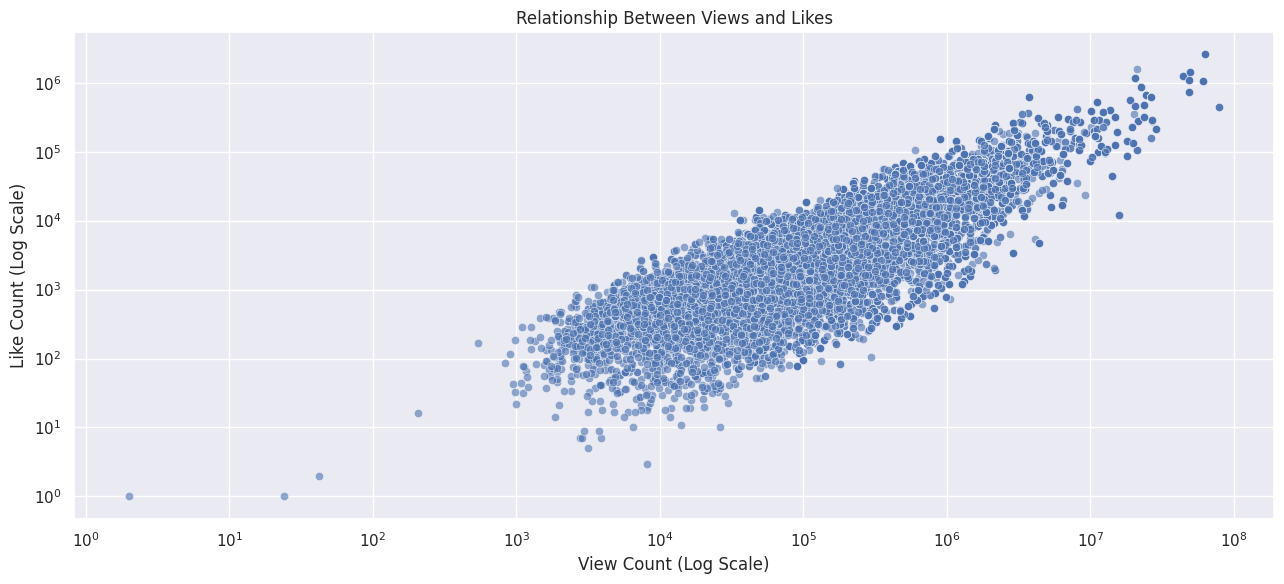

In [100]:
# ============================================================
# QUEST 8: RELATIONSHIP BETWEEN VIEWS AND LIKES
# ============================================================

plot_df = df_clean[
    (df_clean["video_view_count"] > 0) &
    (df_clean["video_like_count"] > 0)
].copy()

plt.figure(figsize=(13, 6))

sns.scatterplot(
    data=plot_df,
    x="video_view_count",
    y="video_like_count",
    alpha=0.6
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Relationship Between Views and Likes"
)

plt.xlabel("View Count (Log Scale)")
plt.ylabel("Like Count (Log Scale)")

plt.tight_layout()
plt.show()

Quest 9: Views vs Likes by Video Category

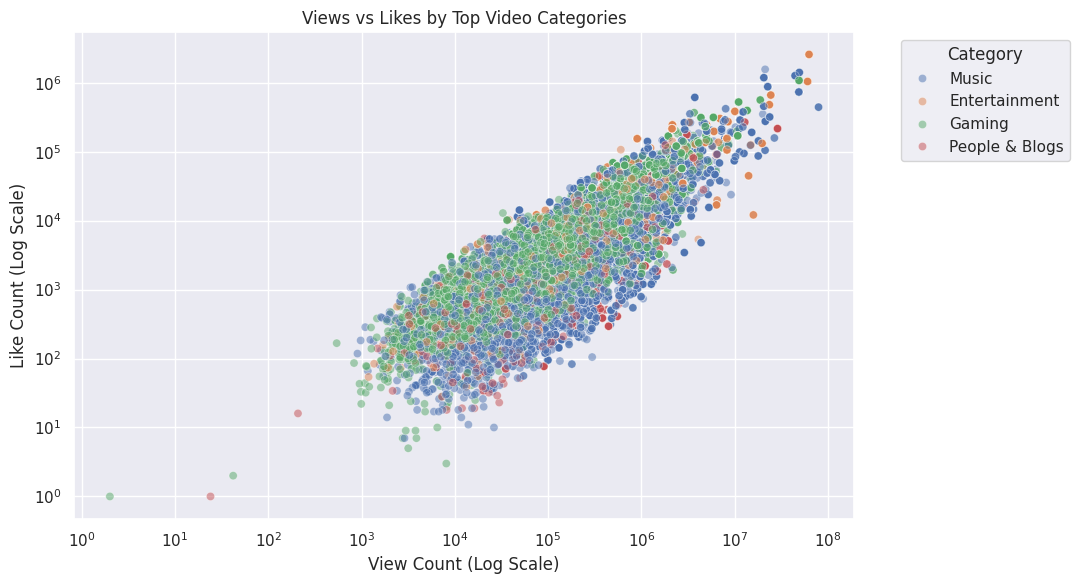

In [98]:
# ============================================================
# QUEST 9: VIEWS VS LIKES BY VIDEO CATEGORY
# ============================================================

top_categories = (
    df_clean["video_category_id"]
    .dropna()
    .value_counts()
    .nlargest(4)
    .index
)

category_plot_df = df_clean[
    df_clean["video_category_id"].isin(top_categories) &
    (df_clean["video_view_count"] > 0) &
    (df_clean["video_like_count"] > 0)
].copy()

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=category_plot_df,
    x="video_view_count",
    y="video_like_count",
    hue="video_category_id",
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Views vs Likes by Top Video Categories"
)

plt.xlabel("View Count (Log Scale)")
plt.ylabel("Like Count (Log Scale)")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    title="Category"
)

plt.tight_layout()
plt.show()

Quest 10: Pairwise Relationships Among Views, Likes, and Comments

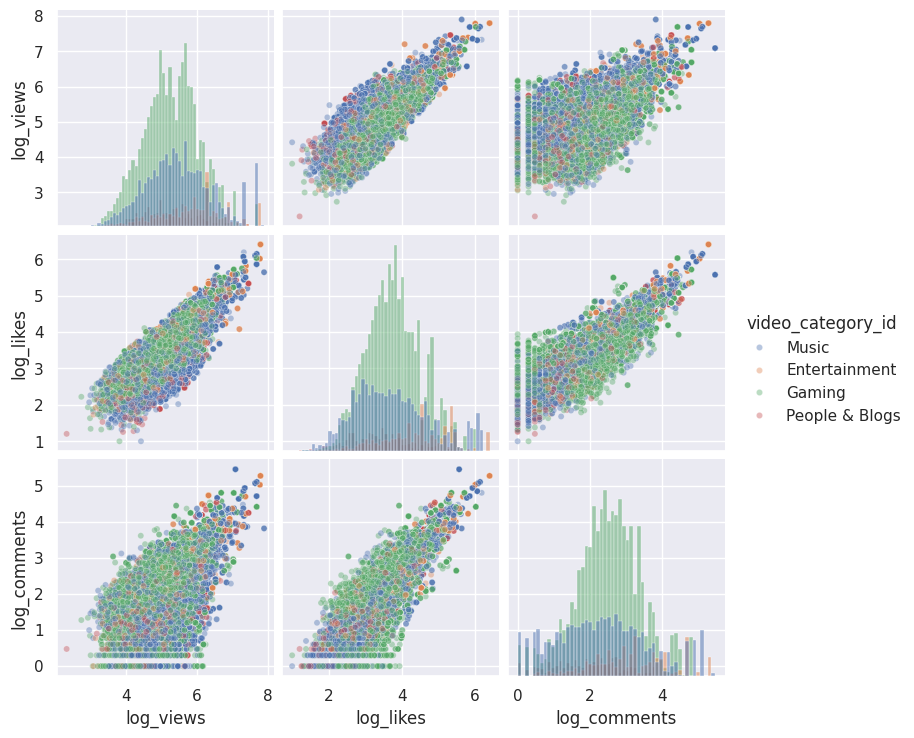

In [99]:
# ============================================================
# QUEST 10: PAIRWISE RELATIONSHIPS AMONG
# VIEWS, LIKES, AND COMMENTS
# ============================================================

pairplot_df = df_clean[
    (df_clean["video_view_count"] > 0) &
    (df_clean["video_like_count"] > 0) &
    (df_clean["video_comment_count"] > 0) &
    (df_clean["video_category_id"].isin(top_categories))
].copy()

pairplot_df["log_views"] = np.log10(
    pairplot_df["video_view_count"]
)

pairplot_df["log_likes"] = np.log10(
    pairplot_df["video_like_count"]
)

pairplot_df["log_comments"] = np.log10(
    pairplot_df["video_comment_count"]
)

sns.pairplot(
    data=pairplot_df,
    vars=[
        "log_views",
        "log_likes",
        "log_comments"
    ],
    hue="video_category_id",
    plot_kws={
        "alpha": 0.4,
        "s": 20
    },
    diag_kind="hist"
)

plt.show()

# **Key Findings**

This analysis examined YouTube trending-video performance across countries
using unique-video, channel-level, and engagement-based metrics.

The analysis focused on:

- The highest-liked unique video.
- The five most-viewed unique videos trending in Indonesia.
- The leading channels by cumulative views across unique videos.
- The top videos by maximum country-level like-to-view ratio.
- Indonesian-trending videos published in 2026 with at least 1 million views.
- Channel performance based on unique video count, average views, and maximum likes.
- The distribution of project-defined Regular, Viral, and Mega Viral categories.
- Relationships among views, likes, and comments using log-scaled visualizations.

## **Data Limitation**

The dataset represents a single trending-date snapshot rather than a
multi-day time series. Therefore, the analysis should be interpreted as a
cross-country snapshot of YouTube trending performance rather than a
longitudinal trend analysis.